# 08 - Model Explainability (SHAP)

Day 2, step 8. "Employee 101 - 82% attrition risk" is not actionable. An HR manager
needs to know *why*, or there is nothing to act on.

SHAP gives both levels the build notes ask for:

* **Global** - what drives attrition across the whole company
* **Local** - why this specific employee was flagged

> **Deviation from the plan.** The notes specify `shap.TreeExplainer`. That call only
> works on tree models, and notebook 07 selected Logistic Regression. Hard-coding
> `TreeExplainer` would raise on the model that actually won, so
> `app/ml/explainer.py` picks the explainer from the fitted estimator - `LinearExplainer`
> here, `TreeExplainer` automatically if a future retrain promotes a tree model.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import train_test_split

from app.ml.explainer import (
    explanation,
    global_importance,
    shap_values,
    split_pipeline,
    top_factors,
)
from app.utils.config import (
    PROCESSED_FILES,
    RANDOM_STATE,
    TEST_SIZE,
    model_metadata,
    model_path,
    risk_level,
)

pd.set_option("display.width", 200)

pipeline = joblib.load(model_path())
metadata = model_metadata()
print(f"model     : {metadata['algorithm']} {metadata['version']}")
print(f"threshold : {metadata['decision_threshold']}")
print(f"ROC-AUC   : {metadata['roc_auc']}")

_, estimator = split_pipeline(pipeline)
print(f"explainer will be chosen for: {type(estimator).__name__}")

model     : LogisticRegression v1.0
threshold : 0.58
ROC-AUC   : 0.8006
explainer will be chosen for: LogisticRegression


In [2]:
df = pd.read_csv(PROCESSED_FILES["attrition"])
y = df["AttritionFlag"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print(f"explaining {len(X_test)} held-out employees against a {len(X_train)}-row background")

explaining 294 held-out employees against a 1176-row background


## Global: what drives attrition company-wide

In [3]:
values, matrix = shap_values(pipeline, X_test, background=X_train)
print("SHAP matrix:", values.shape)

importance = global_importance(pipeline, X_test, background=X_train)
importance.head(20)

Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


SHAP matrix: (294, 58)


Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


,feature,mean_abs_shap,mean_shap
0,AvgYearsPerCompany,0.474663,0.005041
1,YearsSinceLastPromotion,0.473598,-0.071478
2,ManagerStability,0.446437,0.145811
3,OverTime_No,0.347617,-0.035758
4,OverTime_Yes,0.333342,-0.034290
5,MonthlyIncome,0.322511,-0.029593
6,JobRole_Laboratory Technician,0.294473,-0.011632
7,YearsWithCurrManager,0.281057,-0.063362
8,TotalWorkingYears,0.275613,0.053416
9,SatisfactionIndex,0.273811,-0.043450


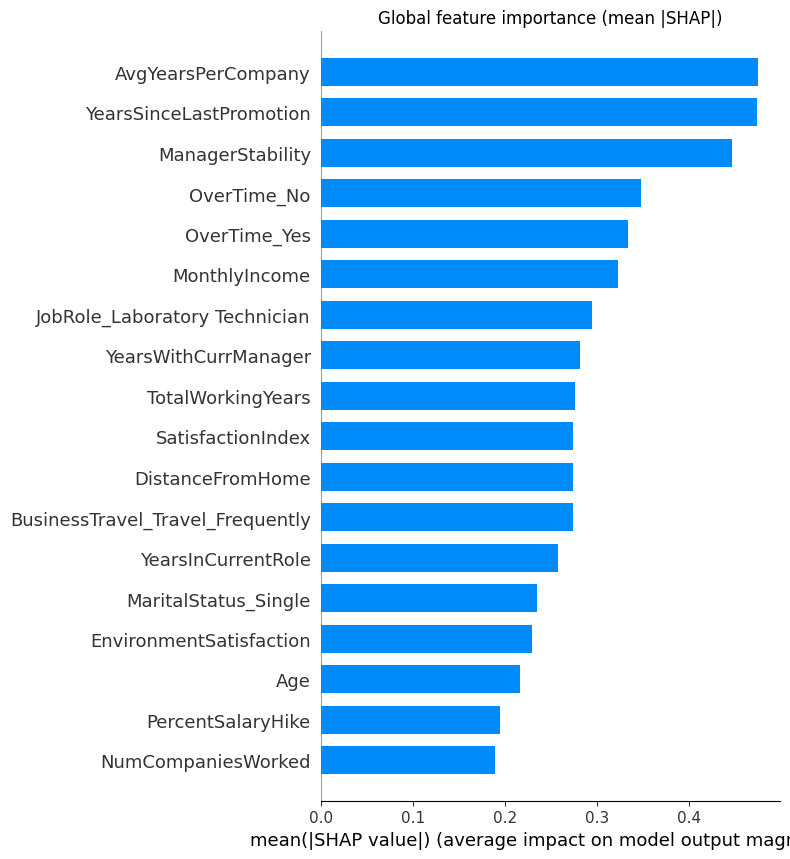

In [4]:
shap.summary_plot(values, matrix, plot_type="bar", max_display=18, show=False)
plt.title("Global feature importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

### The beeswarm view

More informative than the bar chart: each dot is one employee, so it shows both how
much a feature matters and in which direction each value pushes.

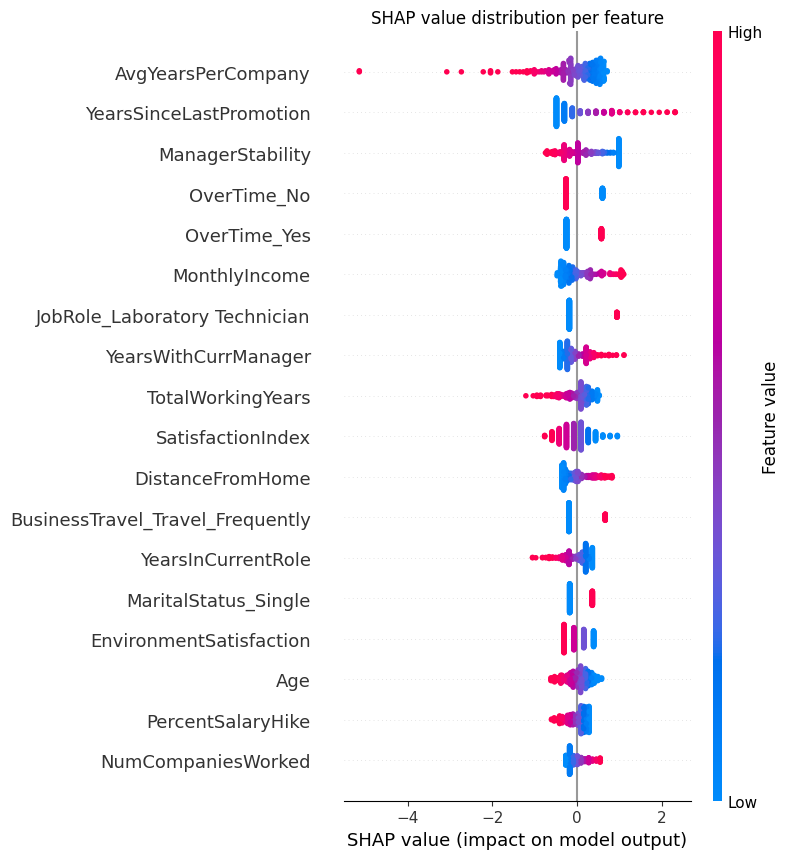

In [5]:
shap.summary_plot(values, matrix, max_display=18, show=False)
plt.title("SHAP value distribution per feature")
plt.tight_layout()
plt.show()

### Reading the global picture

In [6]:
top10 = importance.head(10).copy()
top10["pushes"] = np.where(top10["mean_shap"] > 0, "up (toward leaving)", "down (toward staying)")
print(top10[["feature", "mean_abs_shap", "mean_shap", "pushes"]].to_string(index=False))

                      feature  mean_abs_shap  mean_shap                pushes
           AvgYearsPerCompany       0.474663   0.005041   up (toward leaving)
      YearsSinceLastPromotion       0.473598  -0.071478 down (toward staying)
             ManagerStability       0.446437   0.145811   up (toward leaving)
                  OverTime_No       0.347617  -0.035758 down (toward staying)
                 OverTime_Yes       0.333342  -0.034290 down (toward staying)
                MonthlyIncome       0.322511  -0.029593 down (toward staying)
JobRole_Laboratory Technician       0.294473  -0.011632 down (toward staying)
         YearsWithCurrManager       0.281057  -0.063362 down (toward staying)
            TotalWorkingYears       0.275613   0.053416   up (toward leaving)
            SatisfactionIndex       0.273811  -0.043450 down (toward staying)


### Two things this table does *not* say

**1. `mean_shap` is not a direction.** For a roughly balanced dummy like `OverTime_Yes`,
positive contributions from one half of the workforce cancel against negative ones
from the other, so the population mean sits near zero regardless of how strong the
effect is. `mean_abs_shap` is the importance measure; direction is only meaningful per
employee. The `pushes` column above is included to make that cancellation visible, not
as a finding.

**2. Feature order differs from notebook 06's coefficients, and that is expected.** SHAP
importance is `|coefficient x (value - mean)|` averaged over employees, so it weights a
coefficient by how much that feature actually *varies*. The engineered tenure features -
`AvgYearsPerCompany`, `YearsSinceLastPromotion`, `ManagerStability` - top this ranking
because they are continuous and spread widely, while a job-role dummy has a large
coefficient but is 1 for only a slice of the workforce. Both rankings are correct
answers to different questions: notebook 06 asks "how much does this feature matter
per unit?", SHAP asks "how much did it move real predictions?".

Reassuringly, the same drivers appear in both: overtime, job role, business travel,
tenure and pay relative to tenure. Three independent views agreeing - raw rates,
coefficients, SHAP - is good evidence the model learned structure rather than noise.

SHAP also resolves the puzzle from notebook 06, where `MonthlyIncome` carried a
confusing positive coefficient because of collinearity. Attributing contributions per
prediction reads the pay-related features together instead of as isolated columns.

## Local: why this specific employee?

In [7]:
probabilities = pipeline.predict_proba(X_test)[:, 1]
threshold = metadata["decision_threshold"]

X_report = X_test.copy()
X_report["probability"] = probabilities.round(4)
X_report["risk"] = [risk_level(p, threshold) for p in probabilities]
X_report["actually_left"] = y_test.values

highest = X_report.nlargest(5, "probability")[
    ["EmployeeID", "JobRole", "Department", "OverTime", "probability", "risk", "actually_left"]]
print("Highest-risk employees in the held-out set:")
print(highest.to_string(index=False))

Highest-risk employees in the held-out set:
 EmployeeID              JobRole             Department OverTime  probability risk  actually_left
       1273 Sales Representative                  Sales      Yes       0.9939 HIGH              1
        478 Sales Representative                  Sales      Yes       0.9925 HIGH              1
        959 Sales Representative                  Sales      Yes       0.9862 HIGH              1
       1318      Sales Executive                  Sales      Yes       0.9718 HIGH              1
       1053   Research Scientist Research & Development      Yes       0.9375 HIGH              1


In [8]:
target_position = int(np.argmax(probabilities))
employee = X_test.iloc[[target_position]]
employee_id = int(employee["EmployeeID"].iloc[0])
print(f"Explaining employee {employee_id} - probability {probabilities[target_position]:.4f} "
      f"({risk_level(probabilities[target_position], threshold)} risk)")
employee[["Age", "JobRole", "Department", "OverTime", "MonthlyIncome",
          "JobSatisfaction", "YearsAtCompany", "YearsSinceLastPromotion"]].T

Explaining employee 1273 - probability 0.9939 (HIGH risk)


,911
Age,25
JobRole,Sales Representative
Department,Sales
OverTime,Yes
MonthlyIncome,1118
JobSatisfaction,4
YearsAtCompany,1
YearsSinceLastPromotion,1


Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


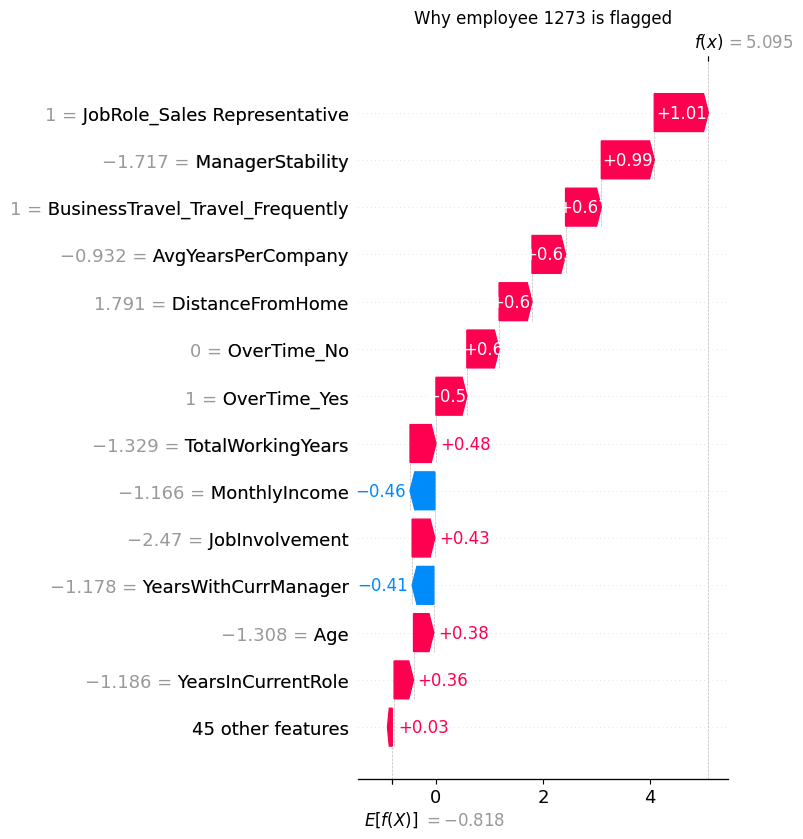

In [9]:
full_explanation = explanation(pipeline, X_test, background=X_train)
shap.plots.waterfall(full_explanation[target_position], max_display=14, show=False)
plt.title(f"Why employee {employee_id} is flagged")
plt.tight_layout()
plt.show()

## The three factors the API returns

The dashboard and the API surface the top three per employee - enough for a manager
to act on, few enough to read at a glance.

In [10]:
factors = top_factors(pipeline, employee, background=X_train, n=3)
for i, f in enumerate(factors, 1):
    print(f"{i}. {f['label']:42s} {f['shap_value']:+.4f}  {f['direction']}")

Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


1. Over time: Yes                             +1.1816  increases risk
2. Job role: Sales Representative             +0.9912  increases risk
3. Manager stability                          +0.9900  increases risk


## Explanations for several employees at once

In [11]:
for position in X_report.nlargest(3, "probability").index:
    row_position = X_test.index.get_loc(position)
    row = X_test.loc[[position]]
    eid = int(row["EmployeeID"].iloc[0])
    p = probabilities[row_position]
    print(f"\nEmployee {eid} - {p:.1%} risk ({risk_level(p, threshold)}), "
          f"{row['JobRole'].iloc[0]}")
    for f in top_factors(pipeline, row, background=X_train, n=3):
        print(f"    {f['label']:40s} {f['shap_value']:+.4f}  {f['direction']}")

Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.



Employee 1273 - 99.4% risk (HIGH), Sales Representative
    Over time: Yes                           +1.1816  increases risk
    Job role: Sales Representative           +0.9912  increases risk
    Manager stability                        +0.9900  increases risk

Employee 478 - 99.2% risk (HIGH), Sales Representative
    Over time: Yes                           +1.1816  increases risk
    Job role: Sales Representative           +0.9912  increases risk
    Business travel: Travel_Frequently       +0.6596  increases risk

Employee 959 - 98.6% risk (HIGH), Sales Representative


Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


    Over time: Yes                           +1.1816  increases risk
    Job role: Sales Representative           +0.9912  increases risk
    Manager stability                        +0.9900  increases risk


### Why `top_factors` aggregates before ranking

Ranking the *encoded* columns directly produced a genuine bug, worth recording
because the output looked plausible:

```
1. JobRole_Sales Representative      +1.0117  increases risk
2. BusinessTravel_Travel_Frequently  +0.6689  increases risk
3. OverTime_No                       +0.6032  increases risk   <- ??
```

Two problems. First, `OverTime_No` carrying a *positive* contribution reads as
nonsense until unpacked: SHAP contribution is `coefficient x (scaled value - mean)`,
`OverTime_No` has a negative coefficient, and for someone who *does* work overtime
the column is 0 - below the population mean - so the product comes out positive. The
maths is right; the label is a trap.

Second, `OverTime_Yes` (+0.5784) was ranked fourth, so one variable stated twice was
about to occupy two of the three slots an HR manager sees.

`app/ml/explainer.py` therefore sums contributions back to the raw column before
ranking, which is also the arithmetically correct total since SHAP is additive.
Overtime's true contribution is +1.18 - the largest single driver for this employee,
and consistent with the coefficient span noted in notebook 06.

In [12]:
print("After aggregating dummies back to their source column:")
for i, f in enumerate(top_factors(pipeline, employee, background=X_train, n=3), 1):
    print(f"{i}. {f['label']:42s} {f['shap_value']:+.4f}  {f['direction']}")

Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


After aggregating dummies back to their source column:
1. Over time: Yes                             +1.1816  increases risk
2. Job role: Sales Representative             +0.9912  increases risk
3. Manager stability                          +0.9900  increases risk


## Sanity check: do explanations agree with the predictions?

SHAP values are additive: the base value plus the sum of a row's contributions must
reproduce the model's own output for that row. If that identity does not hold, the
explanations are decorative rather than faithful - so it is checked, not assumed.

In [13]:
_, est = split_pipeline(pipeline)
decision = est.decision_function(matrix)
reconstructed = full_explanation.base_values + full_explanation.values.sum(axis=1)

max_error = float(np.abs(reconstructed - decision).max())
correlation = float(np.corrcoef(reconstructed, decision)[0, 1])
print(f"base value                     : {float(full_explanation.base_values):.6f}")
print(f"max |reconstructed - actual|   : {max_error:.3e}")
print(f"correlation with model output  : {correlation:.6f}")

assert max_error < 1e-6, "SHAP values do not reconstruct the model output"
print()
print("Exact reconstruction - the explanations are faithful to the model.")

base value                     : -0.818100
max |reconstructed - actual|   : 2.665e-15
correlation with model output  : 1.000000

Exact reconstruction - the explanations are faithful to the model.


C:\Users\Devyansh Aggarwal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## Saving the global view

In [14]:
importance.to_csv(PROCESSED_FILES["attrition"].parent / "shap_global_importance.csv", index=False)
print("written: shap_global_importance.csv")

written: shap_global_importance.csv
